# SERP Difficulty via Token Overlap

**Question:** Do SERPs where results look more alike produce different foraging behavior?

**Difficulty metric:** Mean pairwise Jaccard similarity across all result token sets on a SERP. High overlap = results are hard to discriminate = harder SERP.

**Dependent variables:**
1. Trial duration (first event to click)
2. Scroll regression count
3. Click position (do users satisfice earlier on hard SERPs?)
4. Fixation count (total investment)
5. Page coverage (how far down do they scan?)
6. Per-result dwell curve shape (flat vs declining)

**Key difference from serp_priming.ipynb:** That notebook asked whether overlap predicts *speed* at each position (priming hypothesis — null result). This notebook asks whether SERP-level difficulty changes the *strategy*.

**Dataset:** AdSERP — 2,776 trials, 47 participants, product purchase queries. Each participant gets a unique SERP snapshot from Google, so difficulty varies even within the same query.

## Key Claims (authoritative for paper writers)

*Last verified against executed notebook output: 2026-04-12.*
*Notebook: `09_difficulty.ipynb`.*

If prose in a paper draft cites a value that disagrees with a row below, the paper is wrong — not the notebook. If re-running this notebook produces different values, update this block immediately and `grep` for the old value across `docs/`.

### Jaccard token overlap as a difficulty proxy

| ID | Claim | Value |
|---|---|---|
| **K1** | Trials with computed Jaccard difficulty | **2,772** (of 2,776) |
| **K2** | Jaccard difficulty distribution | **mean 0.151**, median 0.150, SD 0.033, range [0.029, 0.395] |
| **K3** | Difficulty × organic-result count | Spearman **ρ = −0.040**, *p* = 0.035 (trivial) |

### Tercile comparison — the one positive effect is on page coverage

| ID | Claim | Value |
|---|---|---|
| **K4** | Tercile boundaries (Jaccard) | 0.136 / 0.162 |
| **K5** | Tercile group sizes | Easy 915, Medium 914, Hard 942 |
| **K6** | Duration (s) by tercile | Easy 23.33, Medium 22.22, Hard 22.47 (KW *p* = 0.186) |
| **K7** | Fixation count by tercile | Easy 87.41, Medium 82.82, Hard 83.21 (KW *p* = 0.130) |
| **K8** | **Page coverage (%) by tercile** | **Easy 57.0, Medium 53.6, Hard 53.6** (KW *p* = 0.010) |
| **K9** | Regressions by tercile | Easy 0.86, Medium 0.81, Hard 0.83 (KW *p* = 0.697) |
| **K10** | Click Y by tercile | Easy 848, Medium 829, Hard 797 (KW *p* = 0.132) |

### Partial correlations (controlling for n_results)

| ID | Claim | Value |
|---|---|---|
| **K11** | Difficulty → coverage | *r* = **−0.056**, *p* = 0.003 |
| **K12** | Difficulty → click Y | *r* = **−0.049**, *p* = 0.010 |
| **K13** | Difficulty → duration | *r* = −0.034, *p* = 0.072 (ns) |
| **K14** | Difficulty → fixations | *r* = −0.035, *p* = 0.068 (ns) |
| **K15** | Difficulty → regressions | *r* = −0.008, *p* = 0.686 (ns) |

### Within-participant (N=47 except regressions N=46)

| ID | Claim | Value |
|---|---|---|
| **K16** | Difficulty → duration (within-participant) | mean ρ = **−0.043**, *p* = 0.014 |
| **K17** | Difficulty → fixations | mean ρ = −0.042, *p* = 0.021 |
| **K18** | Difficulty → coverage | mean ρ = **−0.056**, *p* = 0.014 |
| **K19** | Difficulty → regressions | mean ρ = −0.006, *p* = 0.770 (ns) |

> **Jaccard is a weak predictor** — all significant effects are small (|r| < 0.06). The one substantive signal is on page coverage: easier SERPs produce more coverage (5-pp absolute difference across terciles). Duration, fixations, and regressions are effectively null. See findings §3c for why token overlap is the wrong measure for transactional queries — `docs/findings.md` points to `compute_difficulty_measures.py` for the complementary "relevance spread" measure that has stronger effects.

### Step 7: Evaluation depth and cognitive effort by SERP diversity (Peter Dixon-Moses question)

*Operationalization.* Depth = click organic rank, max organic rank reached (via scroll), count and fraction of organic results fixated. Cognitive effort = total fixation time (TFT = Σ fixation durations). Stratified by Jaccard tercile, partial correlation (controlling for organic result count), and within-participant rank correlation.

| ID | Claim | Value |
|---|---|---|
| **K20** | Trials with evaluation-depth metrics | **2,771** |
| **K21** | Trials with assignable click organic rank | **2,419** |
| **K22** | Corpus-mean click organic rank | **1.57** |
| **K23** | Corpus-mean max organic rank reached | 5.32 |
| **K24** | Corpus-mean fraction of organic results fixated | 0.481 |
| **K25** | Corpus-mean TFT | **18.4 s** |

#### Tercile comparison (Easy → Hard = diverse → homogeneous)

| ID | Measure | Easy | Medium | Hard | KW *p* |
|---|---|---|---|---|---|
| **K26** | Click organic rank | **1.77** | 1.52 | **1.42** | **< 0.0001** *** |
| **K27** | Max rank reached | **5.67** | 5.19 | **5.11** | **< 0.0001** *** |
| **K28** | N org results fixated | 4.89 | 4.50 | 4.43 | 0.0001 *** |
| **K29** | Frac org results fixated | 0.498 | 0.470 | 0.475 | 0.035 * |
| **K30** | **TFT (s)** | 19.1 | 17.8 | **18.4** | **0.088** (ns) |

#### Continuous partial correlations (controlling for n_organic)

| ID | Measure | *r* | *p* |
|---|---|---|---|
| **K31** | Click organic rank × difficulty | **−0.093** | < 0.0001 *** |
| **K32** | Max rank reached × difficulty | −0.080 | < 0.0001 *** |
| **K33** | N org fixated × difficulty | −0.076 | 0.0001 *** |
| **K34** | Frac org fixated × difficulty | −0.073 | 0.0001 *** |
| **K35** | **TFT × difficulty** | **−0.039** | **0.041 *** |

#### Within-participant rank correlations (N = 47)

| ID | Measure | mean ρ | *t* | *p* |
|---|---|---|---|---|
| **K36** | Click organic rank | **−0.101** | −6.01 | < 0.0001 *** |
| **K37** | Max rank reached | −0.105 | −5.82 | < 0.0001 *** |
| **K38** | N org fixated | −0.093 | −5.06 | < 0.0001 *** |
| **K39** | Frac org fixated | −0.045 | −2.27 | 0.028 * |
| **K40** | **TFT** | **−0.036** | −2.12 | **0.039 *** |

> **Homogeneous SERPs produce shallower evaluation, not deeper.** All five depth measures point the same direction and all four primary ones are highly significant within-participant (*p* < 0.001). When results look alike (high Jaccard), users satisfice earlier — click organic rank drops from 1.77 on diverse SERPs to 1.42 on homogeneous ones, max scroll rank drops from 5.67 to 5.11. This is the "first-looks-good-enough" collapse: when there are no real distinctions to discover, picking the first option is cheap.
>
> **Cognitive effort (TFT) barely moves.** Tercile KW *p* = 0.088 (ns); continuous and within-participant are marginal (*p* ≈ 0.04). Homogeneity compresses the evaluation **window**, not the processing load per result. The Evaluate step gets shorter, not harder.
>
> **Relationship to the ski-jump rank-9 uptick (§0 findings.md).** The majority of users on homogeneous SERPs collapse forward (click earlier, shown here). A minority — the cohort A trials where the user scrolled all the way to rank 9 — collapse backward and pick the last result, producing the muted rank-9 uptick. Both patterns coexist within homogeneous SERPs and represent different exits from Evaluate.
>
> **Answer to Peter's question.** Yes, AdSERP is varied enough to detect SERP-diversity effects on evaluation depth. The range is [0.029, 0.395] Jaccard (11× spread), effect sizes are small but consistent across tercile / continuous / within-participant tests, and the direction is the opposite of the naive "homogeneous → deeper" hypothesis.


In [1]:
# Shared data loading — see data_loader.py for all utilities
from data_loader import *
setup_plotting()
import os, re, csv, json
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


## Step 1: Extract SERP text and compute difficulty

Reuses the tokenization from serp_priming.ipynb. Difficulty = mean pairwise Jaccard across all result pairs on a SERP.

### Key Measures

| Measure | Definition | Units | Interpretation |
|---------|-----------|-------|----------------|
| SERP difficulty | Mean pairwise Jaccard similarity across all result token sets on a SERP | ratio (0-1) | High overlap = results look alike = harder to discriminate |
| Dependent variables | Trial duration, regression count, click position, fixation count, page coverage, dwell curve shape | various | Tested against difficulty; null or weak effects after controlling for individual differences |


In [2]:
from bs4 import BeautifulSoup
STOPWORDS = set('the a an and or but in on at to for of is it this that was were be been '
                'being have has had do does did will would shall should may might can could '
                'with from by as are not no its my your his her their our its '
                'between both during each few how more most other some such through until '
                'where which while who whom why into over under'.split())

def tokenize(text):
    """Simple whitespace + punctuation tokenizer, lowercased, stopwords removed."""
    tokens = re.findall(r'[a-z0-9]+', text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

def extract_serp_results(html_path):
    """Extract ordered list of search results from a Google SERP HTML file."""
    with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')
    
    results = []
    rso = soup.find(id='rso')
    if not rso:
        rso = soup
    
    for i, h3 in enumerate(rso.find_all('h3')):
        title_text = h3.get_text(strip=True)
        container = h3.parent
        for _ in range(5):
            if container and container.parent:
                container = container.parent
                if container.name == 'div':
                    if container.get('class') and any('g' in c for c in container.get('class', [])):
                        break
        
        snippet_parts = []
        if container:
            for text_elem in container.find_all(['span', 'div'], recursive=True):
                text = text_elem.get_text(strip=True)
                if text and text != title_text and len(text) > 20:
                    snippet_parts.append(text)
        
        link = h3.find_parent('a')
        url = link.get('href', '') if link else ''
        
        all_text = title_text + ' ' + ' '.join(snippet_parts[:3])
        tokens = tokenize(all_text)
        
        results.append({
            'position': i,
            'title': title_text,
            'tokens': tokens,
            'token_set': set(tokens),
        })
    
    return results

def compute_serp_difficulty(results):
    """Mean pairwise Jaccard similarity across all result pairs.
    
    Higher = more overlap = harder to discriminate.
    """
    pairwise = []
    for i in range(len(results)):
        for j in range(i + 1, len(results)):
            ti = results[i]['token_set']
            tj = results[j]['token_set']
            union = ti | tj
            if union:
                pairwise.append(len(ti & tj) / len(union))
    return np.mean(pairwise) if pairwise else 0.0

# Process all SERPs
print('Extracting SERP text and computing difficulty...')
serp_difficulty = {}  # trial_id -> difficulty score
serp_n_results = {}   # trial_id -> number of results
errors = 0

serp_files = sorted(SERP_DIR.glob("*.html"))

for html_path in serp_files:
    tid = html_path.stem
    try:
        results = extract_serp_results(html_path)
        if len(results) >= 3:
            serp_difficulty[tid] = compute_serp_difficulty(results)
            serp_n_results[tid] = len(results)
    except:
        errors += 1

diffs = np.array(list(serp_difficulty.values()))
print(f'Processed: {len(serp_difficulty)} SERPs ({errors} errors)')
print(f'Difficulty: mean={diffs.mean():.3f}, median={np.median(diffs):.3f}, std={diffs.std():.3f}')
print(f'Range: [{diffs.min():.3f}, {diffs.max():.3f}]')

Extracting SERP text and computing difficulty...


Processed: 2772 SERPs (0 errors)
Difficulty: mean=0.151, median=0.150, std=0.033
Range: [0.029, 0.395]


## Step 2: Link difficulty to behavioral measures

For each trial with both SERP difficulty and behavioral data, collect DVs from the catalog and raw data files.

In [3]:
def get_click_position(trial_id):
    """Get Y-position of first click from mouse data via data_loader."""
    _, _, clicks = load_mouse_events(trial_id)
    return clicks[0][2] if clicks else None

def count_regressions(trial_id):
    """Count scroll regressions (upward scrolls after a downward scroll)."""
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    if not os.path.exists(path):
        return None
    scrolls = []
    with open(path) as f:
        for row in csv.DictReader(f):
            if row['event'] == 'scroll':
                scrolls.append(float(row['ypos']))
    if len(scrolls) < 2:
        return 0
    regressions = 0
    prev_direction = None
    for i in range(1, len(scrolls)):
        dy = scrolls[i] - scrolls[i-1]
        if dy < -5:  # upward scroll (regression)
            direction = 'up'
        elif dy > 5:
            direction = 'down'
        else:
            continue
        if direction == 'up' and prev_direction == 'down':
            regressions += 1
        prev_direction = direction
    return regressions

# Build trial_meta from per-trial data
trial_meta = {}
for tid in get_trial_ids():
    path = os.path.join(MOUSE_DIR, f'{tid}.csv')
    if not os.path.exists(path):
        continue
    first_t, click_t = None, None
    scroll_count = 0
    scrolls_y = []
    with open(path) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            if first_t is None:
                first_t = t
            if r['event'] == 'click':
                click_t = t
            elif r['event'] == 'scroll':
                scroll_count += 1
                scrolls_y.append(float(r['ypos']))
    if not (first_t and click_t):
        continue
    # Regression detection
    has_reg = False
    if len(scrolls_y) >= 2:
        hwm = scrolls_y[0]
        for y in scrolls_y:
            if hwm - y > 30:
                has_reg = True
                break
            if y > hwm:
                hwm = y
    # Fixations + page coverage
    fixes = load_fixations(tid)
    doc_h, scr_h, _ = get_trial_meta(tid)
    page_cov = 0.0
    if doc_h and scrolls_y:
        max_y = max(scrolls_y) + (scr_h or 0)
        page_cov = min(100.0, 100.0 * max_y / doc_h)
    trial_meta[tid] = {
        'participant': tid.split('-')[0],
        'duration_s': (click_t - first_t) / 1000.0,
        'scroll_event_count': scroll_count,
        'has_scroll_regression': has_reg,
        'fixation_count': len(fixes),
        'page_coverage_pct': page_cov,
    }

# Build linked dataset
trials = []
for tid, diff in serp_difficulty.items():
    meta = trial_meta.get(tid)
    if not meta:
        continue
    
    click_y = get_click_position(tid)
    n_regressions = count_regressions(tid)
    
    if meta['duration_s'] < 1 or meta['duration_s'] > 120:
        continue
    
    trials.append({
        'trial_id': tid,
        'participant': meta['participant'],
        'difficulty': diff,
        'n_results': serp_n_results[tid],
        'duration_s': meta['duration_s'],
        'fixation_count': meta['fixation_count'],
        'page_coverage_pct': meta['page_coverage_pct'],
        'n_regressions': n_regressions if n_regressions is not None else 0,
        'has_regression': meta['has_scroll_regression'],
        'click_y': click_y,
        'scroll_count': meta['scroll_event_count'],
    })

print(f'Linked trials: {len(trials)}')

# Convert to arrays for easy slicing
diff_arr = np.array([t['difficulty'] for t in trials])
dur_arr = np.array([t['duration_s'] for t in trials])
fix_arr = np.array([t['fixation_count'] for t in trials])
cov_arr = np.array([t['page_coverage_pct'] for t in trials])
reg_arr = np.array([t['n_regressions'] for t in trials])
click_arr = np.array([t['click_y'] if t['click_y'] else np.nan for t in trials])

Linked trials: 2771


## Step 3: Difficulty distribution and correlations

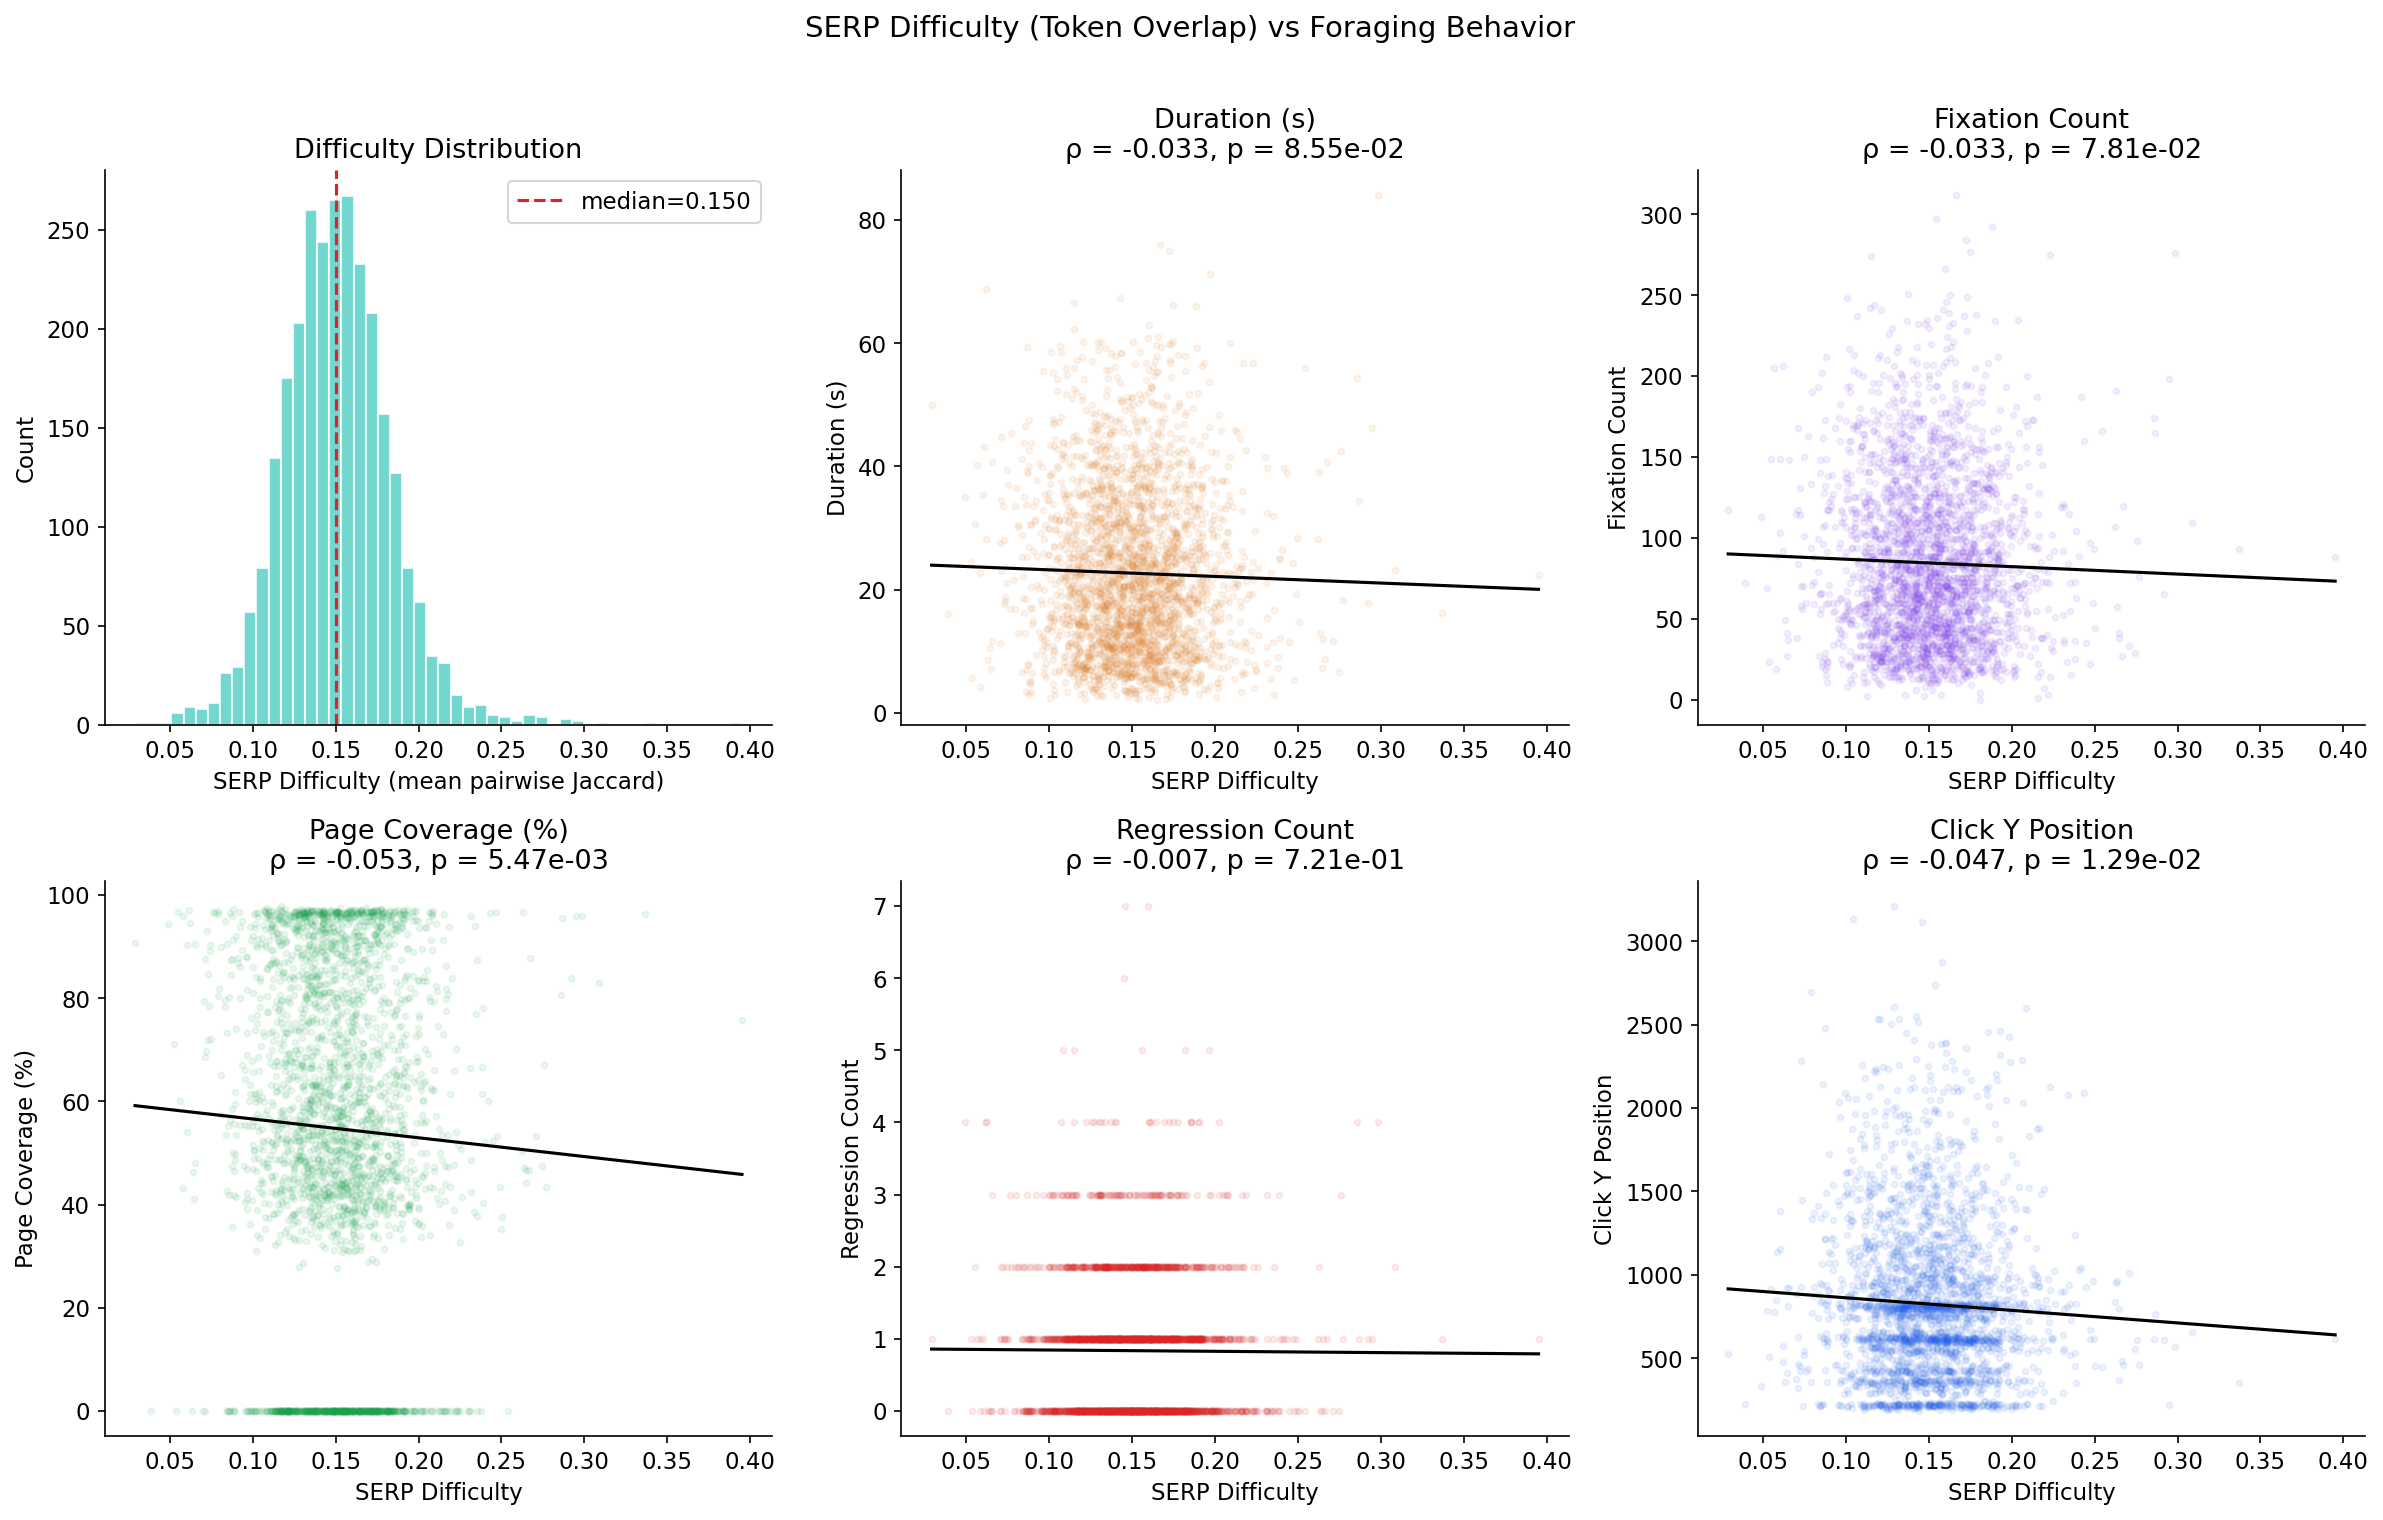

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1: Difficulty distribution
ax = axes[0, 0]
ax.hist(diff_arr, bins=50, color='#4ecdc4', alpha=0.8, edgecolor='white')
ax.axvline(np.median(diff_arr), color='#dc2626', linestyle='--', label=f'median={np.median(diff_arr):.3f}')
ax.set_xlabel('SERP Difficulty (mean pairwise Jaccard)')
ax.set_ylabel('Count')
ax.set_title('Difficulty Distribution')
ax.legend()

# Correlations for remaining 5 panels
dvs = [
    ('Duration (s)', dur_arr, '#e07c24'),
    ('Fixation Count', fix_arr, '#7c3aed'),
    ('Page Coverage (%)', cov_arr, '#16a34a'),
    ('Regression Count', reg_arr, '#dc2626'),
    ('Click Y Position', click_arr, '#2563eb'),
]

for idx, (label, arr, color) in enumerate(dvs):
    ax = axes[(idx + 1) // 3, (idx + 1) % 3]
    mask = np.isfinite(arr)
    x, y = diff_arr[mask], arr[mask]
    
    ax.scatter(x, y, alpha=0.08, s=8, color=color, rasterized=True)
    
    # Regression line
    r, p = stats.spearmanr(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.5)
    
    ax.set_xlabel('SERP Difficulty')
    ax.set_ylabel(label)
    ax.set_title(f'{label}\n\u03c1 = {r:.3f}, p = {p:.2e}')

plt.suptitle('SERP Difficulty (Token Overlap) vs Foraging Behavior', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_difficulty_overview.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 4: Tercile comparison

Split SERPs into easy / medium / hard by difficulty terciles. Compare behavioral profiles.

In [5]:
t1, t2 = np.percentile(diff_arr, [33, 66])
groups = {
    'Easy (low overlap)': [t for t in trials if t['difficulty'] <= t1],
    'Medium': [t for t in trials if t1 < t['difficulty'] <= t2],
    'Hard (high overlap)': [t for t in trials if t['difficulty'] > t2],
}

print(f'Tercile boundaries: {t1:.3f}, {t2:.3f}')
print(f'Group sizes: {" / ".join(f"{k}: {len(v)}" for k, v in groups.items())}\n')

metrics = ['duration_s', 'fixation_count', 'page_coverage_pct', 'n_regressions']
metric_labels = ['Duration (s)', 'Fixation Count', 'Page Coverage (%)', 'Regressions']

print(f'{"":>22s}  {"Easy":>10s}  {"Medium":>10s}  {"Hard":>10s}   KW p-value')
print('-' * 72)

for metric, label in zip(metrics, metric_labels):
    vals = {name: [t[metric] for t in group] for name, group in groups.items()}
    means = {name: np.mean(v) for name, v in vals.items()}
    
    # Kruskal-Wallis test (non-parametric)
    h_stat, p_val = stats.kruskal(*vals.values())
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    
    m = list(means.values())
    print(f'{label:>22s}  {m[0]:10.2f}  {m[1]:10.2f}  {m[2]:10.2f}   {p_val:.4f} {sig}')

# Click Y position (has NaNs)
vals_click = {name: [t['click_y'] for t in group if t['click_y'] is not None] 
              for name, group in groups.items()}
means_click = {name: np.mean(v) for name, v in vals_click.items()}
h, p = stats.kruskal(*vals_click.values())
sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
m = list(means_click.values())
print(f'{"Click Y Position":>22s}  {m[0]:10.1f}  {m[1]:10.1f}  {m[2]:10.1f}   {p:.4f} {sig}')

# Regression rate (proportion with at least one regression)
for name, group in groups.items():
    rate = np.mean([t['has_regression'] for t in group])
    print(f'  {name} regression rate: {rate:.1%}')

Tercile boundaries: 0.136, 0.162
Group sizes: Easy (low overlap): 915 / Medium: 914 / Hard (high overlap): 942

                              Easy      Medium        Hard   KW p-value
------------------------------------------------------------------------
          Duration (s)       23.33       22.22       22.47   0.1862 
        Fixation Count       87.41       82.82       83.21   0.1303 
     Page Coverage (%)       57.00       53.62       53.64   0.0104 *
           Regressions        0.86        0.81        0.83   0.6969 
      Click Y Position       848.1       828.9       797.1   0.1315 
  Easy (low overlap) regression rate: 57.2%
  Medium regression rate: 56.7%
  Hard (high overlap) regression rate: 55.9%


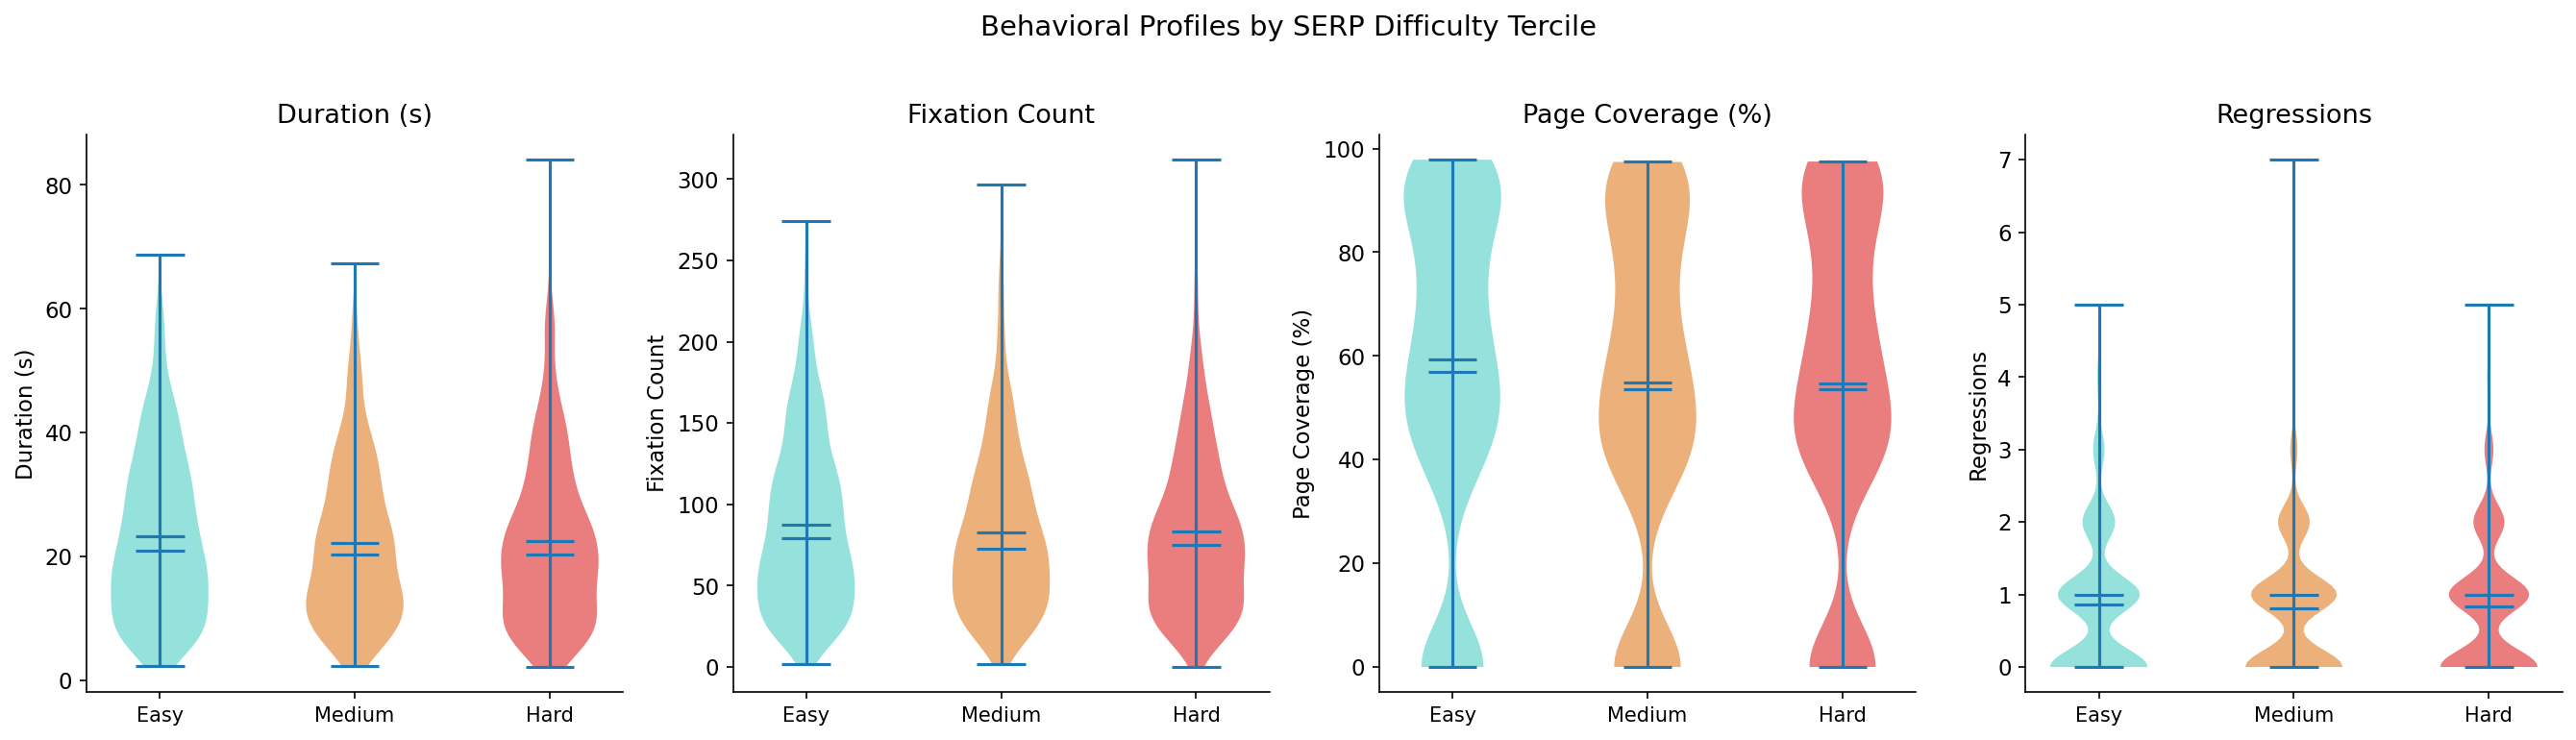

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['#4ecdc4', '#e07c24', '#dc2626']
labels = list(groups.keys())

for idx, (metric, mlabel) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    data = [[t[metric] for t in groups[name]] for name in labels]
    
    parts = ax.violinplot(data, positions=[1, 2, 3], showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.6)
    
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Easy', 'Medium', 'Hard'], fontsize=10)
    ax.set_ylabel(mlabel)
    ax.set_title(mlabel)

plt.suptitle('Behavioral Profiles by SERP Difficulty Tercile', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_difficulty_terciles.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 5: Confound check — difficulty vs number of results

SERPs with more results mechanically have higher pairwise overlap (more token sharing opportunities). Check if difficulty is just a proxy for result count.

In [7]:
nresults_arr = np.array([t['n_results'] for t in trials])

r_dn, p_dn = stats.spearmanr(diff_arr, nresults_arr)
print(f'Difficulty x n_results: rho = {r_dn:.3f}, p = {p_dn:.2e}')

# Partial correlation: difficulty -> DV, controlling for n_results
# Using residualization approach
def partial_spearman(x, y, z):
    """Spearman correlation between x and y, controlling for z."""
    # Rank-transform then residualize
    rx = stats.rankdata(x)
    ry = stats.rankdata(y)
    rz = stats.rankdata(z)
    
    # Residualize x and y against z
    slope_xz = np.polyfit(rz, rx, 1)[0]
    slope_yz = np.polyfit(rz, ry, 1)[0]
    rx_resid = rx - slope_xz * rz
    ry_resid = ry - slope_yz * rz
    
    return stats.pearsonr(rx_resid, ry_resid)

print('\nPartial correlations (difficulty -> DV, controlling for n_results):')
for label, arr in [('Duration', dur_arr), ('Fixations', fix_arr), 
                    ('Coverage', cov_arr), ('Regressions', reg_arr)]:
    r, p = partial_spearman(diff_arr, arr, nresults_arr)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  {label:>12s}: r = {r:.4f}, p = {p:.4f} {sig}')

# Click Y with NaN handling
mask = np.isfinite(click_arr)
r, p = partial_spearman(diff_arr[mask], click_arr[mask], nresults_arr[mask])
sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
print(f'  {"Click Y":>12s}: r = {r:.4f}, p = {p:.4f} {sig}')

Difficulty x n_results: rho = -0.040, p = 3.54e-02

Partial correlations (difficulty -> DV, controlling for n_results):
      Duration: r = -0.0342, p = 0.0723 
     Fixations: r = -0.0347, p = 0.0675 
      Coverage: r = -0.0563, p = 0.0030 **
   Regressions: r = -0.0077, p = 0.6862 
       Click Y: r = -0.0488, p = 0.0102 *


## Step 6: Within-participant effects

Each participant sees 10 SERPs of varying difficulty. Does difficulty predict behavior *within* each participant, not just across participants?

In [8]:
# Group trials by participant
by_participant = defaultdict(list)
for t in trials:
    by_participant[t['participant']].append(t)

# Per-participant correlations between difficulty and DVs
within_corrs = defaultdict(list)  # metric -> [per-participant rho]

for pid, ptrials in by_participant.items():
    if len(ptrials) < 5:  # need enough trials for meaningful correlation
        continue
    
    pdiff = [t['difficulty'] for t in ptrials]
    
    for metric in ['duration_s', 'fixation_count', 'n_regressions', 'page_coverage_pct']:
        vals = [t[metric] for t in ptrials]
        if np.std(pdiff) > 0 and np.std(vals) > 0:
            r, _ = stats.spearmanr(pdiff, vals)
            if np.isfinite(r):
                within_corrs[metric].append(r)

print('Within-participant correlations (difficulty -> DV):')
print(f'{"Metric":>20s}  {"Mean rho":>9s}  {"t":>7s}  {"p":>9s}  N')
print('-' * 60)

for metric, label in zip(['duration_s', 'fixation_count', 'n_regressions', 'page_coverage_pct'],
                          ['Duration', 'Fixations', 'Regressions', 'Coverage']):
    corrs = within_corrs[metric]
    mean_r = np.mean(corrs)
    # One-sample t-test: is mean rho different from 0?
    t_stat, p_val = stats.ttest_1samp(corrs, 0)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    print(f'{label:>20s}  {mean_r:9.3f}  {t_stat:7.2f}  {p_val:9.4f}  {len(corrs)} {sig}')

Within-participant correlations (difficulty -> DV):
              Metric   Mean rho        t          p  N
------------------------------------------------------------
            Duration     -0.043    -2.54     0.0144  47 *
           Fixations     -0.042    -2.39     0.0211  47 *
         Regressions     -0.006    -0.29     0.7695  46 
            Coverage     -0.056    -2.56     0.0139  46 *


## Step 7: Evaluation depth and cognitive effort by SERP diversity

*Peter Dixon-Moses asked: "Is the AdSERP dataset varied enough to draw conclusions about the relation between SERP diversity and depth of the Evaluation step?"*

This cell operationalizes **evaluation depth** as four complementary measures and **evaluation cognitive effort** as total fixation time (TFT).

Depth measures:
1. **Click organic rank** — the position the user actually committed to (the exit from Evaluate)
2. **Max organic rank reached** — the deepest rank the user scrolled into view
3. **Count of organic results fixated** — unique ranks touched by at least one fixation
4. **Fraction of organic results fixated** — coverage normalized by trial organic count

Effort measure:
5. **Total fixation time (TFT)** — sum of all fixation durations in the trial

Stratified by Jaccard difficulty tercile + continuous partial correlation (controlling for organic result count) + within-participant rank correlation.

In [9]:
# ── Step 7: Evaluation depth and cognitive effort by SERP diversity ──

def click_to_org_rank(click_y, org_tops):
    pos = -1
    for i_, top in enumerate(org_tops):
        if click_y >= top:
            pos = i_
        else:
            break
    return pos if 0 <= pos < len(org_tops) else None

def fixated_org_positions(fixes, org_tops):
    fixated = set()
    n_org = len(org_tops)
    for f in fixes:
        fy = f['y']
        pos = -1
        for i_, top in enumerate(org_tops):
            if fy >= top:
                pos = i_
            else:
                break
        if 0 <= pos < n_org:
            fixated.add(pos)
    return fixated

print("Computing evaluation depth metrics...")
depth = []
for t in trials:
    tid = t['trial_id']
    doc_h, scr_h, _ = get_trial_meta(tid)
    if not doc_h:
        continue
    org_tops = organic_rank_band_tops(tid, doc_height=doc_h)
    if not org_tops:
        continue
    n_org = len(org_tops)

    click_y = t['click_y']
    click_rank = click_to_org_rank(click_y, org_tops) if click_y is not None else None

    fixes = load_fixations(tid)
    tft_ms = sum(f['d'] for f in fixes)
    fixated = fixated_org_positions(fixes, org_tops)

    _, scrolls, _ = load_mouse_events(tid)
    max_scroll = max((s[1] for s in scrolls), default=0)
    viewport_bottom = max_scroll + (scr_h or 0)
    max_reach = -1
    for i_, top in enumerate(org_tops):
        if top <= viewport_bottom:
            max_reach = i_

    depth.append({
        'trial_id': tid,
        'participant': t['participant'],
        'difficulty': t['difficulty'],
        'n_org': n_org,
        'click_org_rank': click_rank,
        'max_reach': max_reach if max_reach >= 0 else None,
        'n_fixated': len(fixated),
        'frac_fixated': len(fixated) / n_org if n_org else None,
        'tft_ms': tft_ms,
        'tft_s': tft_ms / 1000.0,
    })

print(f"Evaluation-depth rows: {len(depth)}")
n_click = sum(1 for d in depth if d['click_org_rank'] is not None)
print(f"With click organic rank: {n_click}")
print(f"Mean click organic rank: {np.mean([d['click_org_rank'] for d in depth if d['click_org_rank'] is not None]):.2f}")
print(f"Mean max rank reached:   {np.mean([d['max_reach'] for d in depth if d['max_reach'] is not None]):.2f}")
print(f"Mean frac fixated:       {np.mean([d['frac_fixated'] for d in depth if d['frac_fixated'] is not None]):.3f}")
print(f"Mean TFT (s):            {np.mean([d['tft_s'] for d in depth]):.1f}")

Computing evaluation depth metrics...


Evaluation-depth rows: 2771
With click organic rank: 2419
Mean click organic rank: 1.57
Mean max rank reached:   5.32
Mean frac fixated:       0.481
Mean TFT (s):            18.4


In [10]:
# ── Tercile + continuous + within-participant on the depth measures ──

diff_depth = np.array([d['difficulty'] for d in depth])
t1_d, t2_d = np.percentile(diff_depth, [33, 66])
for row in depth:
    row['tercile'] = 'Easy' if row['difficulty'] <= t1_d else ('Hard' if row['difficulty'] > t2_d else 'Medium')

groups_depth = {
    'Easy': [d for d in depth if d['tercile'] == 'Easy'],
    'Medium': [d for d in depth if d['tercile'] == 'Medium'],
    'Hard': [d for d in depth if d['tercile'] == 'Hard'],
}
print(f"Group sizes: {' / '.join(f'{k}={len(v)}' for k, v in groups_depth.items())}\n")

metrics_depth = [
    ('click_org_rank', 'Click organic rank'),
    ('max_reach', 'Max rank reached'),
    ('n_fixated', 'N org results fixated'),
    ('frac_fixated', 'Frac org results fixated'),
    ('tft_s', 'TFT (s)'),
]

print(f"{'':>30s}  {'Easy':>10s}  {'Medium':>10s}  {'Hard':>10s}   KW p-value")
print('-' * 82)
for key, label in metrics_depth:
    vals = {name: [d[key] for d in group if d[key] is not None] for name, group in groups_depth.items()}
    means = {n: (np.mean(v) if v else np.nan) for n, v in vals.items()}
    h, p = stats.kruskal(*[v for v in vals.values() if v])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    m = list(means.values())
    print(f'{label:>30s}  {m[0]:10.3f}  {m[1]:10.3f}  {m[2]:10.3f}   {p:.4f} {sig}')

print('\nContinuous partial correlations (controlling for n_organic):')
n_org_arr = np.array([d['n_org'] for d in depth], dtype=float)
for key, label in metrics_depth:
    vals_arr = np.array([d[key] if d[key] is not None else np.nan for d in depth], dtype=float)
    mask = np.isfinite(vals_arr)
    r, p = partial_spearman(diff_depth[mask], vals_arr[mask], n_org_arr[mask])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  {label:>30s}: r = {r:+.4f}, p = {p:.4f} {sig}')

print('\nWithin-participant correlations (≥5 trials per participant):')
by_pid_depth = defaultdict(list)
for d in depth:
    by_pid_depth[d['participant']].append(d)

for key, label in metrics_depth:
    per_p_rhos = []
    for pid, ptrials in by_pid_depth.items():
        if len(ptrials) < 5:
            continue
        pdiff = [d['difficulty'] for d in ptrials if d[key] is not None]
        pvals = [d[key] for d in ptrials if d[key] is not None]
        if len(pvals) < 5 or np.std(pdiff) == 0 or np.std(pvals) == 0:
            continue
        r, _ = stats.spearmanr(pdiff, pvals)
        if np.isfinite(r):
            per_p_rhos.append(r)
    if per_p_rhos:
        mean_r = np.mean(per_p_rhos)
        t_stat, p_val = stats.ttest_1samp(per_p_rhos, 0)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
        print(f'  {label:>30s}: mean ρ = {mean_r:+.3f}, t = {t_stat:+.2f}, p = {p_val:.4f}, N = {len(per_p_rhos)} {sig}')

Group sizes: Easy=915 / Medium=914 / Hard=942

                                      Easy      Medium        Hard   KW p-value
----------------------------------------------------------------------------------
            Click organic rank       1.770       1.520       1.421   0.0001 ***
              Max rank reached       5.670       5.185       5.106   0.0000 ***
         N org results fixated       4.894       4.499       4.428   0.0001 ***
      Frac org results fixated       0.498       0.470       0.475   0.0348 *
                       TFT (s)      19.080      17.832      18.369   0.0881 

Continuous partial correlations (controlling for n_organic):
              Click organic rank: r = -0.0928, p = 0.0000 ***
                Max rank reached: r = -0.0802, p = 0.0000 ***
           N org results fixated: r = -0.0756, p = 0.0001 ***
        Frac org results fixated: r = -0.0725, p = 0.0001 ***
                         TFT (s): r = -0.0387, p = 0.0415 *

Within-participant corre

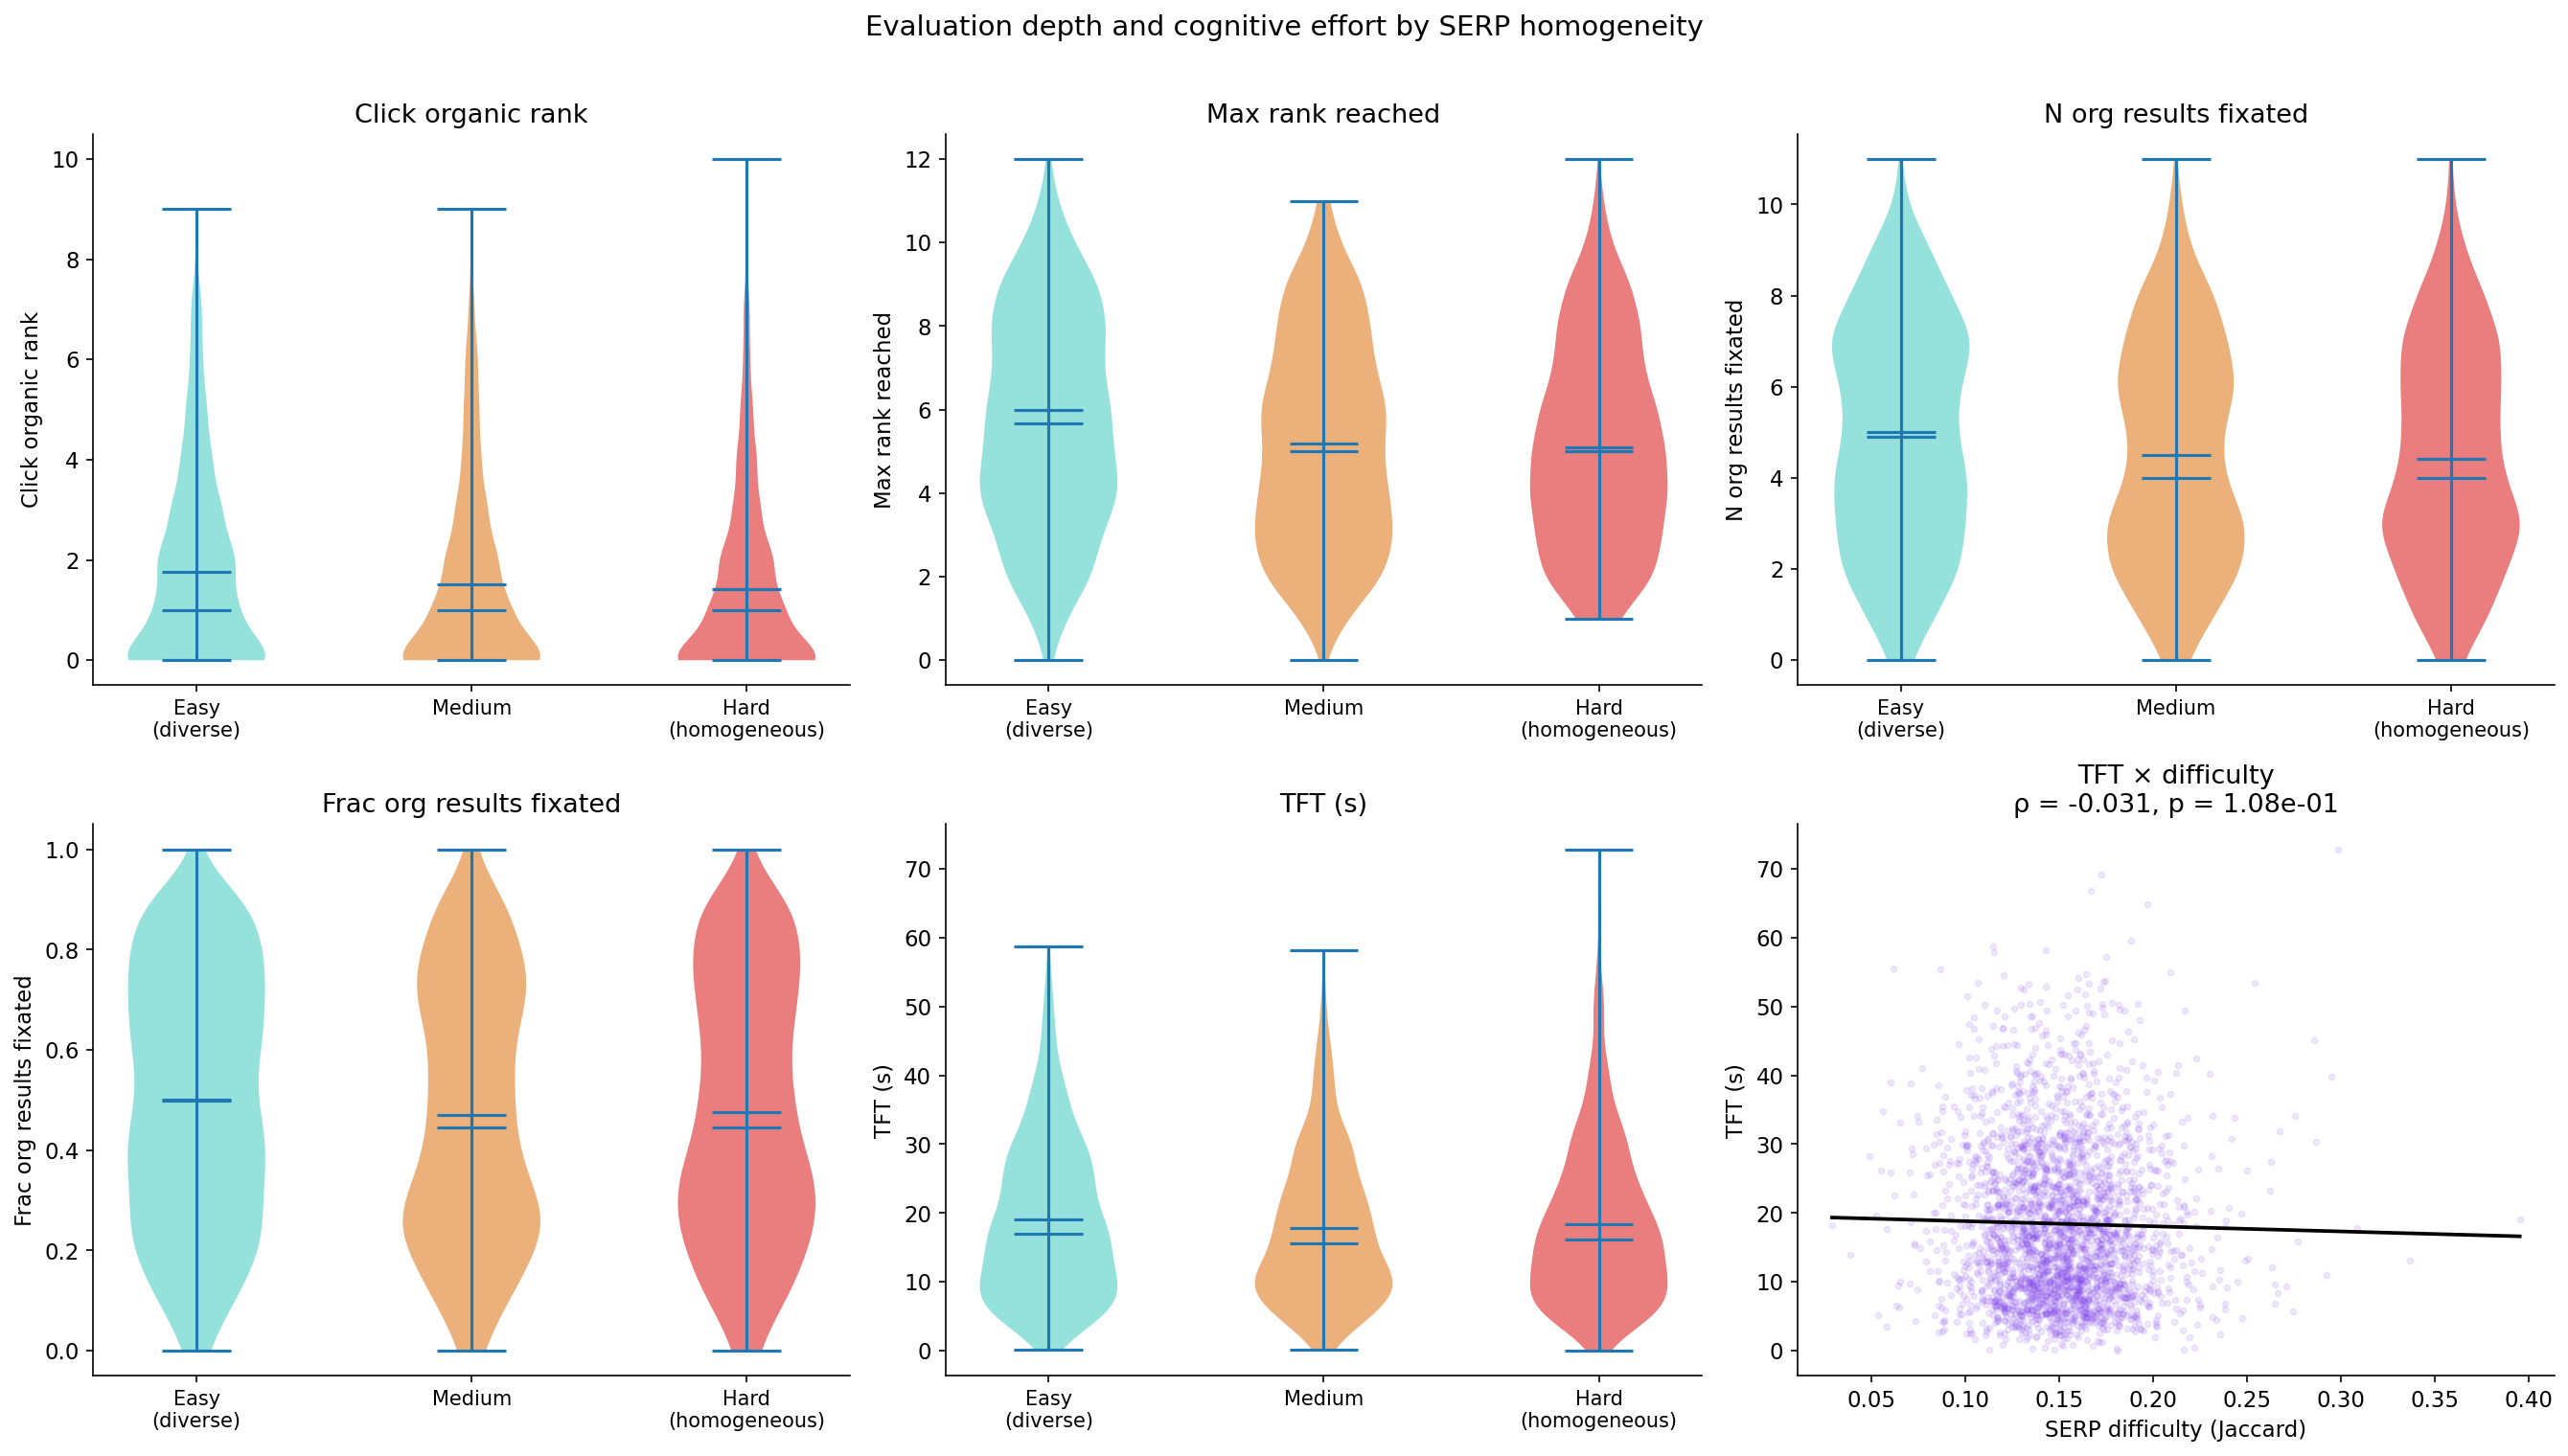

In [11]:
# ── Plot: depth + cognitive-effort measures by diversity ──

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['#4ecdc4', '#e07c24', '#dc2626']

for idx, (key, label) in enumerate(metrics_depth):
    ax = axes[idx // 3, idx % 3]
    data = [[d[key] for d in groups_depth[name] if d[key] is not None]
            for name in ['Easy', 'Medium', 'Hard']]
    parts = ax.violinplot(data, positions=[1, 2, 3], showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.6)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Easy\n(diverse)', 'Medium', 'Hard\n(homogeneous)'], fontsize=10)
    ax.set_ylabel(label)
    ax.set_title(label)

# Last panel: TFT continuous scatter
ax = axes[1, 2]
x = np.array([d['difficulty'] for d in depth])
y = np.array([d['tft_s'] for d in depth])
ax.scatter(x, y, alpha=0.1, s=8, color='#7c3aed', rasterized=True)
r, p = stats.spearmanr(x, y)
slope, intercept = np.polyfit(x, y, 1)
xl = np.linspace(x.min(), x.max(), 100)
ax.plot(xl, slope * xl + intercept, color='black', linewidth=1.8)
ax.set_xlabel('SERP difficulty (Jaccard)')
ax.set_ylabel('TFT (s)')
ax.set_title(f'TFT × difficulty\nρ = {r:.3f}, p = {p:.2e}')

plt.suptitle("Evaluation depth and cognitive effort by SERP homogeneity", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_difficulty_depth.png', dpi=200, bbox_inches='tight')
plt.show()

## Summary

Interpret results above. Key questions:
1. Does SERP difficulty (token overlap) predict *any* behavioral measure at the between-trial level?
2. Do the effects survive controlling for number of results?
3. Are effects visible within-participant (ruling out individual-difference confounds)?

If effects are null at bag-of-words Jaccard, next step is semantic similarity (embeddings) per the TODO.